In [2]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
from pathlib import Path
import h5py
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Get the current working directory
current_path = os.getcwd()
two_levels_up = os.path.dirname(os.path.dirname(os.getcwd()))
parent_directory = two_levels_up#os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
sys.path.append(os.path.dirname(os.getcwd()))

from class_analysis import metrics_creator
from class_analysis import create_df_to_plot
from ssh_connect import ssh_che
from connect_CHE import download_data
from read_save import read_data
from class_analysis import graph_maker_1plot
from matplotlib.colors import LogNorm
from scipy.stats import chi2
from astropy import constants as C
from astropy import units as u
from ulens_params import event_param, microlensing_params
from detection_criteria import mag
import rubin_sim
import rubin_sim.maf as maf
from rubin_sim.data import get_baseline
from plot_hist import *
import pyarrow.dataset as ds
from filter_df import prepare_and_compute_metrics

Parent Directory: /home/anibal/microlensing/simulation_Rubin/roman_rubin


In [3]:
labelsparams = lambda p: labels[p]
label_m1 = lambda p: f'$\\alpha({labels[p]})$'
label_m3 = lambda p :f'$\\gamma({labels[p]})$'
label_m2 = lambda p :f'$\\beta({labels[p]})$'

label_dict={'piE':r"$\pi_E$",
            'tE':r"$t_E$",
            'rho':r"$\rho$",
            'piEE':r'$\pi_{EE}$',
            'piEN':r'$\pi_{EN}$'}
CLR = ['k','blue','r','orange','purple','green']
label_met = ['met1','met2','met3']
label_rmet_lat = [r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$", r"$\frac{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman}}$", 
                 r"$\frac{\sigma_{\pi_E}/\hat{\pi}_E(Roman+Rubin)}{\sigma_{\pi_E}/\hat{\pi}_E(Roman)}$"]
dict_cat_peak = {"A":"peak in Rubin+Roman",
                "B":"peak in Rubin",
                "C":"peak in Roman"}

param_names = ['u0', 'tE', 'piE','piEE','piEN']
param_labels = [r'$\log_{10}(u_0)$', r'$t_E [day]$', r'$\log_{10}(\pi_E)$', r'$\log_{10}(|\pi_{EE}|)$',r'$\log_{10}(|\pi_{EN}|)$']


In [4]:
import pyarrow.dataset as ds

model = 'FSPL'
path= parent_directory+f'/all_results/{"FFP"}/'
fit_rr = pd.read_parquet(path+"/fit_rr.parquet")
fit_roman =  pd.read_parquet(path+"/fit_roman.parquet")
# true = pd.read_parquet(path+"/true.parquet")

dataset_true = ds.dataset(parent_directory+"/all_results/data_FFP/true_ds/", format="parquet", partitioning="hive")
dataset_fit_rr = ds.dataset(parent_directory+"/all_results/data_FFP/fit_rr_ds/", format="parquet", partitioning="hive")
dataset_fit_roman = ds.dataset(parent_directory+"/all_results/data_FFP/fit_roman_ds/", format="parquet", partitioning="hive")

true = dataset_true.to_table().to_pandas()
fit_rr = dataset_fit_rr.to_table().to_pandas()
fit_roman =  dataset_fit_roman.to_table().to_pandas()


In [5]:
if model=="PSPL":
    params = ["tE", "piE", "piEE", "piEN"]
elif model=="FSPL":
    params = ["tE", "piE","rho", "piEE", "piEN"]

In [6]:
detector_6_pts = pd.read_csv("/home/anibal/microlensing/simulation_Rubin/roman_rubin/all_results/deviation_results.csv")
# detector_6_pts[detector_6_pts["decision"]==True]
detector_6_pts["Set"] = detector_6_pts["n"]+1
detector_6_pts["Source"] = detector_6_pts["event"]

k = ["Source", "Set"]

det_keys = (detector_6_pts.loc[detector_6_pts["decision"] == True, k]
            .drop_duplicates())

true_detected = true.merge(det_keys, on=k, how="inner")

(
    fit_rr, fit_roman, true,
    met_1_rr, met_2_rr, met_3_rr,
    met_1_roman, met_2_roman, met_3_roman
) = prepare_and_compute_metrics(
    true=true_detected,
    fit_rr=fit_rr,
    fit_roman=fit_roman,
    model=model,
    metrics_creator=metrics_creator,
    compute_mass_metrics=compute_mass_metrics,
    make_total_npeak_flag=True,         # opcional
    total_npeak_threshold=10,           # opcional
)

Filas después del merge: 63909
Filas después del merge: 63909


In [7]:
df_mask = true[['Source','Set']]
met_1_rr_filtered = met_1_rr.merge(df_mask, on=['Source', 'Set'], how='inner')
met_2_rr_filtered = met_2_rr.merge(df_mask, on=['Source', 'Set'], how='inner')
met_3_rr_filtered = met_3_rr.merge(df_mask, on=['Source', 'Set'], how='inner')
met_1_roman_filtered = met_1_roman.merge(df_mask, on=['Source', 'Set'], how='inner')
met_2_roman_filtered = met_2_roman.merge(df_mask, on=['Source', 'Set'], how='inner')
met_3_roman_filtered = met_3_roman.merge(df_mask, on=['Source', 'Set'], how='inner')

In [8]:
# Aplicar la función a tus métricas
met1_ratio = compute_ratio(met_1_rr, met_1_roman, params)
met2_ratio = compute_ratio(met_2_rr, met_2_roman, params)
met3_ratio = compute_ratio(met_3_rr, met_3_roman, params)

# Plot lightcurves

In [9]:
# fit_rr[]

In [10]:
true

,Source,Set,t0,u0,tE,rho,piEN,piEE,Category,mass,...,y_rpeak,u,u_peak,u_npeak,u_lpeak,u_rpeak,peak_flag,flag_relevance,total_npeak,flag_total_npeak_gt10
0,100,1,2.461653e+06,1.379105,0.741328,0.017075,0.224941,0.234854,None,0.005315,...,NaN,NaN,0.0,0.0,NaN,NaN,C,True,44.0,1
1,10007,1,2.462911e+06,-0.117783,9.192547,0.002846,0.549593,0.519165,None,0.013333,...,0.0,NaN,0.0,0.0,NaN,NaN,A,True,550.0,1
2,10016,1,2.461476e+06,-1.814517,2.078341,0.007295,-0.237724,0.091874,None,0.015008,...,0.0,NaN,0.0,0.0,NaN,NaN,C,True,123.0,1
3,10018,1,2.462563e+06,0.445721,1.550059,0.005106,-0.166253,-0.223341,None,0.014075,...,NaN,NaN,0.0,0.0,NaN,NaN,C,True,92.0,1
5,10034,1,2.462954e+06,0.896718,4.696767,0.004004,0.059508,0.629892,None,0.012807,...,0.0,NaN,0.0,0.0,NaN,NaN,A,True,284.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69478,99959,4,2.461831e+06,0.240637,0.752504,0.008451,0.092607,-1.504031,None,0.001435,...,NaN,NaN,0.0,0.0,NaN,NaN,C,True,45.0,1
69479,99960,4,2.461870e+06,1.236541,0.839405,0.012655,0.817347,0.384800,None,0.002697,...,0.0,NaN,0.0,0.0,NaN,NaN,A,True,50.0,1
69480,99961,4,2.462743e+06,0.082054,33.159756,0.006275,-2.063306,-1.057021,None,0.003660,...,3.0,1.0,1.0,1.0,0.0,1.0,A,True,2001.0,1
69481,99966,4,2.462759e+06,-1.320880,8.750082,0.001184,1.433268,-0.559340,None,0.015717,...,NaN,NaN,0.0,0.0,NaN,NaN,C,True,521.0,1


The file already exist
check_event  : Everything looks fine...


KeyError: "No encontré 'u0' ni sus alias ['u_center']."

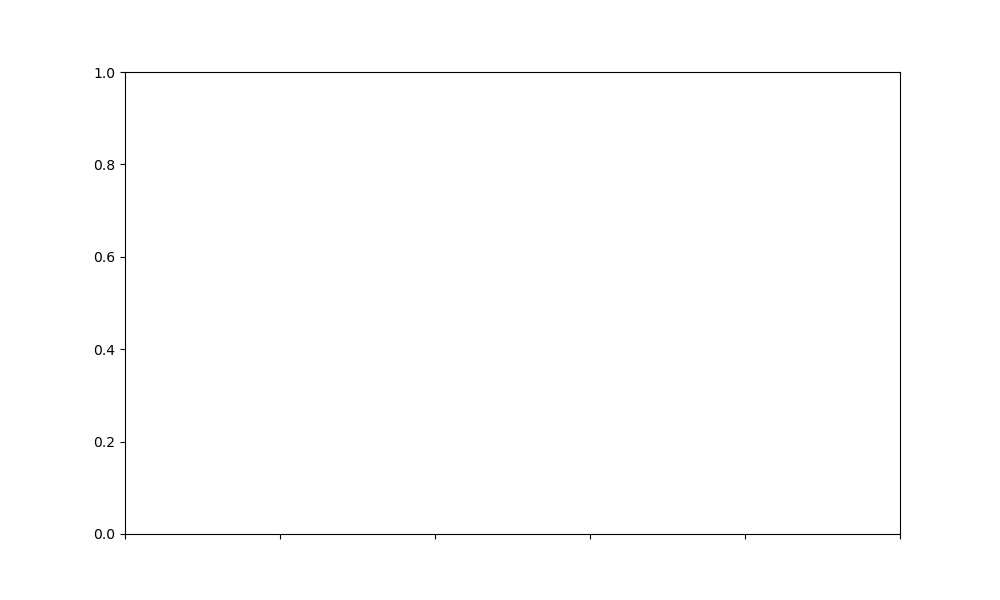

In [13]:
ssh = ssh_che()
sources_array = [12831]
model = "FSPL"
nset = 1
system_type = 'FFP'

path_run = f'/share/storage3/rubin/microlensing/romanrubin/RR2025/finalv2_set/{system_type}/'
path_save = os.getcwd()+f'/lightcurves/{system_type}_{nset}/'

if not os.path.exists(path_save):
    os.makedirs(path_save, exist_ok=True)
if not os.path.exists(path_save+f'Event_{sources_array[0]}.h5')==True:
    download_data(ssh,sources_array, nset, path_run, path_save)
else:
    print('The file already exist')

df_to_plot = create_df_to_plot(sources_array, model,path_save)
%matplotlib ipympl
# %matplotlib inline
plt.close('all')

path_save = '/home/anibal/'
path_ephemerides = '/home/anibal/microlensing/simulation_Rubin/roman_rubin/ephemerides/Roman_positions.npy'
fig, axes = graph_maker_1plot(df_to_plot, model, False, path_save, path_ephemerides)

indices, strings, pyLIMA_parameters, TRILEGAL_params, bands, GENULENS_row, TRILEGAL_row= read_data(df_to_plot['path_event'].iloc[0])
axes[0].set_xlim(pyLIMA_parameters['t0']-100,pyLIMA_parameters['t0']+100)
delta_t = np.sqrt((pyLIMA_parameters['rho']+1)**2+pyLIMA_parameters['u0']**2)
axes[0].axvspan(pyLIMA_parameters['t0']-3.5*pyLIMA_parameters['tE']*delta_t,pyLIMA_parameters['t0']+3.5*pyLIMA_parameters['tE']*delta_t,color='blue',alpha=0.25)
# axes[0].axvspan(pyLIMA_parameters['t0']-pyLIMA_parameters['tE'],pyLIMA_parameters['t0']+pyLIMA_parameters['tE'],color='blue',alpha=0.25)
# axes[0].axvline(params['t0'])
# axes[0].axvspan(params['t_center']-1*params['tE']*np.sqrt(params['mass_ratio']),
#                 params['t_center']+1*params['tE']*np.sqrt(params['mass_ratio']),
#                 alpha=0.15,
#                 color='blue',label="t_{c}\pm t_{Ep}")
# axes[0].axvspan(params['t_center']-5*params['tE']*np.sqrt(params['rho']),params['t_center']+5*params['tE']*np.sqrt(params['rho']),alpha=0.25,color='red')
# plt.tight_layout()

plt.show()

In [50]:
print(np.sqrt((pyLIMA_parameters['rho']+1)**2+pyLIMA_parameters['u0']**2))

1.7163662732274845


In [46]:
data_fit_rr = np.load(df_to_plot["path_fit_rr"][0], allow_pickle = True).item()
cov_matrix = data_fit_rr["covariance_matrix"]
print("errors piE", np.sqrt(np.diag(cov_matrix))[3], np.sqrt(np.diag(cov_matrix))[4])
print("best_model piE", data_fit_rr["best_model"][3],  data_fit_rr["best_model"][4])
print(cov_matrix[2,3]/(np.sqrt(cov_matrix[2,2])*np.sqrt(cov_matrix[3,3])))

errors piE 0.04395807523979174 2.8129176853421645
best_model piE 0.0027309424026981176 1.0507029043446332
-0.10839023186190716


In [73]:
from pyLIMA import event
from pyLIMA import telescopes
from pyLIMA.models import FSPLarge_model
def model_rubin_roman(Source, event_params, path_ephemerides, model,ORIGIN, bands):
    '''
    Perform fit for Rubin and Roman data for fspl, usbl and pspl
    '''

    lightcurve_dict = {}
    for f in ['W149', 'u', 'g', 'r','i','z','y']:
        lightcurve_dict[f] = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T

    RA, DEC = 267.92497054815516, -29.152232510353276
    e = event.Event(ra=RA, dec=DEC)
    if len(lightcurve_dict["u"]) + len(lightcurve_dict["g"]) + len(lightcurve_dict["r"]) + len(lightcurve_dict["i"]) + len(lightcurve_dict["z"]) + len(lightcurve_dict["y"]) == 0:
        e.name = 'Event_Roman_' + str(int(Source))
        name_roman = 'W149'
    else:
        e.name = 'Event_RR_' + str(int(Source))
        name_roman = 'W149'
    tel_list = []
    tel1 = telescopes.Telescope(name=name_roman, camera_filter='W149',
                                lightcurve=lightcurve_dict['W149'],
                                lightcurve_names=['time', 'mag', 'err_mag'],
                                lightcurve_units=['JD', 'mag', 'mag'],
                                location='Space')
    ephemerides = np.load(path_ephemerides)
    tel1.spacecraft_positions = {'astrometry': [], 'photometry': ephemerides}
    e.telescopes.append(tel1)
    tel_list.append('Roman')
    # lsst_lc_list = [lsst_u, lsst_g, lsst_r, lsst_i, lsst_z, lsst_y]
    lsst_bands = "ugrizy"
    for j in range(len(lsst_bands)):
        if len(lightcurve_dict[lsst_bands[j]]) != 0:
            tel = telescopes.Telescope(name=lsst_bands[j], camera_filter=lsst_bands[j],
                                       lightcurve=lightcurve_dict[lsst_bands[j]],
                                       lightcurve_names=['time', 'mag', 'err_mag'],
                                       lightcurve_units=['JD', 'mag', 'mag'],
                                       location='Earth')
            e.telescopes.append(tel)
            tel_list.append(lsst_bands[j])
    e.check_event()
    t_guess = float(event_params['t_center']) if 't_center' in event_params else float(event_params.get('t0', None))
    if model == 'FSPL':
        pyLIMAmodel = FSPLarge_model.FSPLargemodel(e, parallax=['Full', t_guess])
    elif model == 'USBL':
        pyLIMAmodel = USBL_model.USBLmodel(e, origin=ORIGIN,
                                           blend_flux_parameter='ftotal',
                                           parallax=['Full', t_guess])
    elif model == 'USBL_NoPiE':
        pyLIMAmodel = USBL_model.USBLmodel(e, origin=ORIGIN, blend_flux_parameter='ftotal')
    elif model == 'PSPL':
        pyLIMAmodel = PSPL_model.PSPLmodel(e,parallax=['Full', t_guess], blend_flux_parameter='ftotal')
    return pyLIMAmodel



In [46]:
# 

In [74]:
from pyLIMA.fits import objective_functions
pyLIMA_model = model_rubin_roman(100, pyLIMA_parameters, path_ephemerides, model,[strings[2],[0,0]], bands)



check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS


In [67]:
filter_list = ["W149","u","g","r","i","z","y"]
f = objective_functions.all_telescope_photometric_chi2
npts = sum([len(bands[b]) for b in filter_list])
npar = 8
dof = npts - npar
print(f(pyLIMA_model, pyLIMA_parameters)/dof)

59.59263904982391


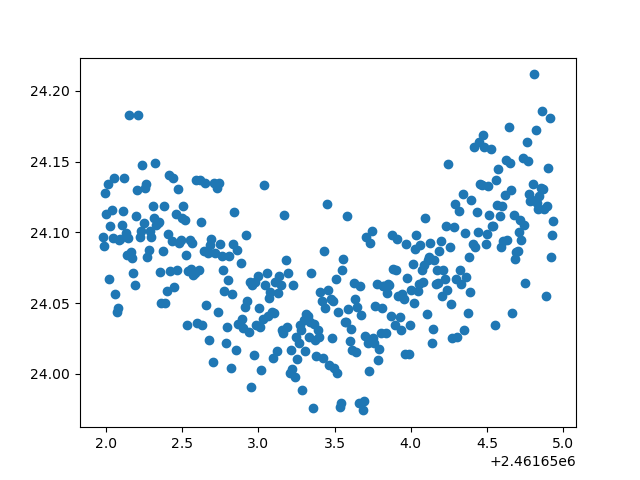

In [32]:
plt.close("all")
indices, strings, pyLIMA_parameters, TRILEGAL_params, bands, GENULENS_row, TRILEGAL_row= read_data(df_to_plot['path_event'].iloc[0])

for f in filter_list:
    bands[f]=bands[f][(bands[f]["time"]>pyLIMA_parameters["t0"]-2*pyLIMA_parameters["tE"])&(bands[f]["time"]<pyLIMA_parameters["t0"]+2*pyLIMA_parameters["tE"])]
    plt.plot(bands[f]["time"],bands[f]["mag"],linestyle='',marker='o')
plt.show()

In [ ]:

def deviation_from_constant(pyLIMA_parameters,
                            lightcurves,
                            nsigma=3.0,
                            nmin=6,
                            window="all"):
    """
    Decide si existe una racha (run) de >= nmin puntos consecutivos (ordenados en tiempo,
    combinando TODAS las bandas) que estén por encima del baseline en magnitudes en más de
    nsigma sigmas, i.e. mag < mag_baseline - nsigma * err_mag.

    Parámetros
    ----------
    pyLIMA_parameters : dict
        Debe contener 't0', 'tE' y, por banda, 'ftotal_<band>' (ej. 'ftotal_g').
    lightcurves : dict OR iterable
        - Si es dict: {band: table}, donde table (QTable/Table/pandas-like) tiene columnas
          'time', 'mag', 'err_mag'.
        - Si es iterable (tipo pyLIMA_telescopes): cada elemento debe tener .name y
          .lightcurve con columnas 'time', 'mag', 'err_mag'. (Compatibilidad hacia atrás.)
    nsigma : float
    nmin : int
    window : {"all", "t0pm_tE", "t0pm_2tE"}

    Returns
    -------
    (passes, max_run) : (bool, int)
    """

    ZP = {'W149': 27.615, 'u': 27.03, 'g': 28.38, 'r': 28.16,
          'i': 27.85, 'z': 27.46, 'y': 26.68}

    t0 = pyLIMA_parameters['t0']
    tE = pyLIMA_parameters['tE']

    # ===================== NUEVO BLOQUE (1): normalización de input =====================
    # Convierte `lightcurves` a un iterador uniforme de (band, table)
    def _iter_band_tables(lightcurves_obj):
        # Caso A: dict {band: table}
        if isinstance(lightcurves_obj, dict):
            for band, tab in lightcurves_obj.items():
                yield band, tab
            return

        # Caso B: iterable tipo pyLIMA_telescopes (compatibilidad)
        for telo in lightcurves_obj:
            if not hasattr(telo, "lightcurve") or telo.lightcurve is None:
                continue
            band = getattr(telo, "name", None)
            if band is None:
                continue
            yield band, telo.lightcurve

    # ===================== NUEVO BLOQUE (2): extracción robusta de columnas =====================
    def _col_as_numpy(tab, colname):
        """
        Devuelve np.ndarray (float) para una columna. Soporta astropy Quantity (vía .value).
        """
        if colname not in tab.colnames if hasattr(tab, "colnames") else colname not in tab:
            raise KeyError(f"Falta la columna '{colname}' en la tabla de la banda.")

        col = tab[colname]
        # astropy Quantity / Column con .value
        if hasattr(col, "value"):
            arr = np.asarray(col.value, dtype=float)
        else:
            arr = np.asarray(col, dtype=float)
        return arr

    all_t = []
    all_cond = []

    for band, tab in _iter_band_tables(lightcurves):
        # Tablas vacías
        try:
            # algunas tablas soportan len(tab)
            if len(tab) == 0:
                continue
        except Exception:
            pass

        if band not in ZP:
            # banda desconocida -> no podemos armar baseline consistente
            continue

        key = f'ftotal_{band}'
        if key not in pyLIMA_parameters:
            # si no hay ftotal_<band> no se puede estimar baseline para esa banda
            continue

        ftotal = pyLIMA_parameters[key]
        if ftotal is None or not np.isfinite(ftotal) or ftotal <= 0:
            continue

        mag_baseline = ZP[band] - 2.5 * np.log10(ftotal)

        # columnas
        try:
            x = _col_as_numpy(tab, "time")
            y = _col_as_numpy(tab, "mag")
            z = _col_as_numpy(tab, "err_mag")
        except KeyError:
            # si faltan columnas, salteamos esa banda
            continue

        if x.size == 0:
            continue

        # ventana temporal
        if window == "t0pm_tE":
            mask = (t0 - tE < x) & (x < t0 + tE)
        elif window == "t0pm_2tE":
            mask = (t0 - 2 * tE < x) & (x < t0 + 2 * tE)
        else:
            mask = np.ones_like(x, dtype=bool)

        if not np.any(mask):
            continue

        # condición de desviación (evento más brillante que baseline por nsigma)
        cond = y[mask] < (mag_baseline - nsigma * z[mask])

        all_t.append(x[mask])
        all_cond.append(cond.astype(bool))

    if len(all_t) == 0:
        return False, 0

    t = np.concatenate(all_t)
    cond = np.concatenate(all_cond)

    idx = np.argsort(t)
    cond_sorted = cond[idx]

    # racha máxima de True consecutivos
    max_run = run = 0
    for v in cond_sorted:
        if v:
            run += 1
            if run > max_run:
                max_run = run
        else:
            run = 0

    return (max_run >= nmin), int(max_run)



In [ ]:


for n in range(4):
    path_set = Path( path_run+"set_sim"+str(n+1))
    for h5_file in path_set.glob("*.h5"):
        indices, strings, pyLIMA_parameters, TRILEGAL_params, bands, GENULENS_row, TRILEGAL_row= read_data(h5_file)
        decision, max_run =  deviation_from_constant(pyLIMA_parameters, bands,
                                  nsigma=3.0, nmin=6, window="all")   

In [ ]:
indices, strings, pyLIMA_parameters, TRILEGAL_params, bands, GENULENS_row, TRILEGAL_row= read_data(df_to_plot['path_event'].iloc[0])

In [ ]:
decision,max_run =  deviation_from_constant(pyLIMA_parameters, bands,
                          nsigma=3.0, nmin=6, window="all")
decision, max_run

In [ ]:
def plot_3sigma_deviations_full(pyLIMA_parameters, lightcurves):
    ZP = {'W149': 27.615, 'u': 27.03, 'g': 28.38, 'r': 28.16,
          'i': 27.85, 'z': 27.46, 'y': 26.68}

    t0 = pyLIMA_parameters['t0']
    tE = pyLIMA_parameters['tE']

    fig, ax = plt.subplots(figsize=(12,7))

    colors = {
        'W149': 'black', 'u': 'purple', 'g': 'green', 'r': 'red',
        'i': 'orange', 'z': 'brown', 'y': 'blue'
    }

    for band, tab in lightcurves.items():

        if band not in ZP:
            continue
        key = f'ftotal_{band}'
        if key not in pyLIMA_parameters:
            continue

        ftotal = pyLIMA_parameters[key]
        if ftotal <= 0:
            continue

        mag_baseline = ZP[band] - 2.5*np.log10(ftotal)

        x = np.asarray(tab['time'])
        y = np.asarray(tab['mag'])
        z = np.asarray(tab['err_mag'])

        cond = y < (mag_baseline - 3*z)

        # TODOS los puntos con barras de error
        ax.errorbar(x, y, yerr=z, fmt='.', ms=4,
                    alpha=0.35,
                    color=colors.get(band,'gray'),
                    label=f"{band} data")

        # baseline
        ax.axhline(mag_baseline,
                   color=colors.get(band,'gray'),
                   linestyle='--', alpha=0.4)

        # puntos que activan el criterio
        ax.errorbar(x[cond], y[cond], yerr=z[cond],
                    fmt='o', ms=8,
                    mec='k', mew=1.2,
                    color=colors.get(band,'gray'),
                    label=f"{band} >3σ")

    # marcar región del evento
    ax.axvline(t0, color='k', ls=':')
    ax.axvspan(t0 - tE, t0 + tE, alpha=0.08, color='gray', label='t0±tE')

    ax.invert_yaxis()
    ax.set_xlabel("Time")
    ax.set_ylabel("Magnitude")
    ax.set_title("3σ Deviations Over Full Light Curve")
    ax.legend(ncol=2, fontsize=9)
    ax.grid(alpha=0.2)

    return fig, ax

fig, ax = plot_3sigma_deviations_full(pyLIMA_parameters, bands)
plt.show()

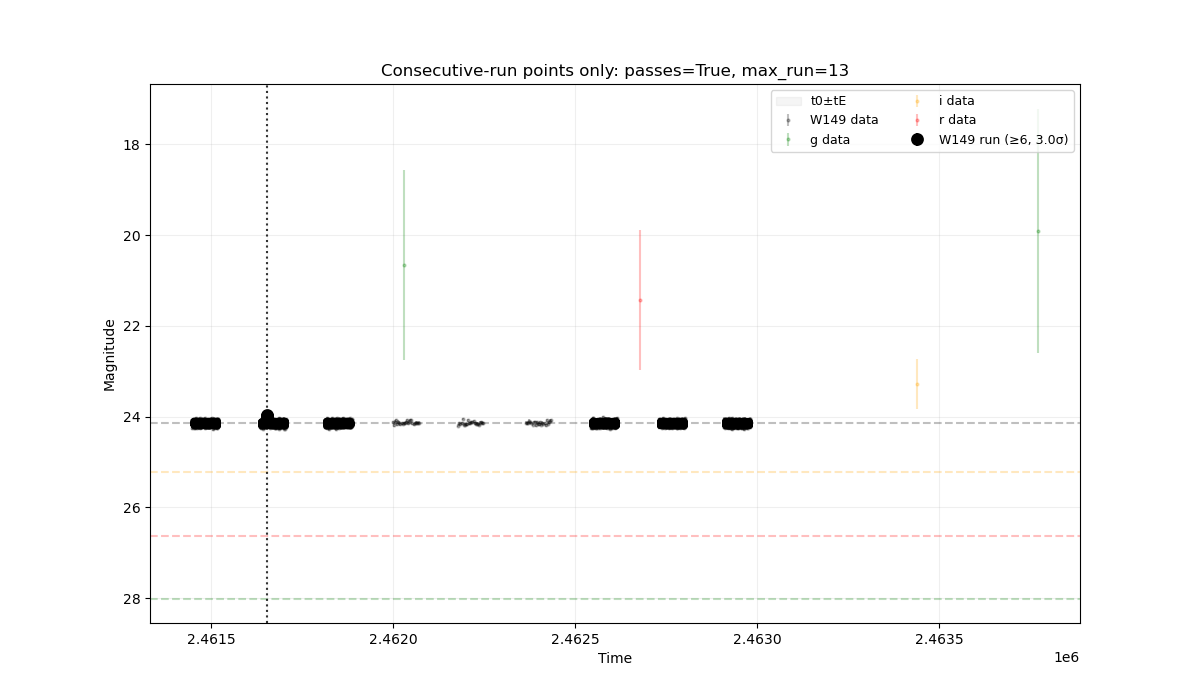

In [68]:
def plot_only_consecutive_run_points(pyLIMA_parameters,
                                     lightcurves,
                                     nsigma=3.0,
                                     nmin=6,
                                     window="all",
                                     show_baseline=True,
                                     show_t0_tE=True):
    """
    Grafica todas las curvas (tenues) y resalta SOLO los puntos que pertenecen a
    alguna racha de >= nmin puntos consecutivos (en tiempo, combinando TODAS las bandas)
    que cumplen: mag < mag_baseline - nsigma*err_mag.

    Devuelve:
      fig, ax, run_mask_sorted, meta_sorted
    donde:
      - run_mask_sorted es un bool array (ordenado por tiempo) que indica los puntos resaltados
      - meta_sorted es un dict con arrays ordenados (t, mag, err, band, baseline, ...)
    """

    ZP = {'W149': 27.615, 'u': 27.03, 'g': 28.38, 'r': 28.16,
          'i': 27.85, 'z': 27.46, 'y': 26.68}

    t0 = pyLIMA_parameters['t0']
    tE = pyLIMA_parameters['tE']

    # Colores (si preferís no fijar colores, lo saco)
    colors = {'W149': 'black', 'u': 'purple', 'g': 'green', 'r': 'red',
              'i': 'orange', 'z': 'brown', 'y': 'blue'}

    # --------- 1) Recolectar puntos globales (t, mag, err, band, baseline, cond) ----------
    all_t, all_mag, all_err, all_band, all_baseline, all_cond = [], [], [], [], [], []

    for band, tab in lightcurves.items():
        if band not in ZP:
            continue

        key = f'ftotal_{band}'
        if key not in pyLIMA_parameters:
            continue

        ftotal = pyLIMA_parameters[key]
        if ftotal is None or (not np.isfinite(ftotal)) or (ftotal <= 0):
            continue

        mag_baseline = ZP[band] - 2.5*np.log10(ftotal)

        x = np.asarray(tab['time'], dtype=float)
        y = np.asarray(tab['mag'], dtype=float)
        z = np.asarray(tab['err_mag'], dtype=float)

        if x.size == 0:
            continue

        # ventana temporal (igual que en tu criterio)
        if window == "t0pm_tE":
            mask = (t0 - tE < x) & (x < t0 + tE)
        elif window == "t0pm_2tE":
            mask = (t0 - 2*tE < x) & (x < t0 + 2*tE)
        else:
            mask = np.ones_like(x, dtype=bool)

        if not np.any(mask):
            continue

        xw, yw, zw = x[mask], y[mask], z[mask]
        cond = yw < (mag_baseline - nsigma*zw)

        all_t.append(xw)
        all_mag.append(yw)
        all_err.append(zw)
        all_band.append(np.array([band]*xw.size))
        all_baseline.append(np.array([mag_baseline]*xw.size))
        all_cond.append(cond.astype(bool))

    if len(all_t) == 0:
        fig, ax = plt.subplots(figsize=(12, 7))
        ax.set_title("No hay datos válidos para graficar (ninguna banda pasó los filtros).")
        return fig, ax, np.array([], dtype=bool), {}

    t = np.concatenate(all_t)
    mag = np.concatenate(all_mag)
    err = np.concatenate(all_err)
    band = np.concatenate(all_band)
    baseline = np.concatenate(all_baseline)
    cond = np.concatenate(all_cond)

    # --------- 2) Ordenar globalmente por tiempo ----------
    idx = np.argsort(t)
    t_s = t[idx]
    mag_s = mag[idx]
    err_s = err[idx]
    band_s = band[idx]
    baseline_s = baseline[idx]
    cond_s = cond[idx]

    # --------- 3) Encontrar rachas consecutivas True con longitud >= nmin ----------
    run_mask = np.zeros_like(cond_s, dtype=bool)

    i = 0
    N = cond_s.size
    while i < N:
        if not cond_s[i]:
            i += 1
            continue
        j = i
        while j < N and cond_s[j]:
            j += 1
        # segmento [i, j)
        if (j - i) >= nmin:
            run_mask[i:j] = True
        i = j

    passes = bool(np.any(run_mask))
    max_run = 0
    # calcular max_run (de las rachas True en cond_s, no en run_mask)
    r = 0
    for v in cond_s:
        if v:
            r += 1
            max_run = max(max_run, r)
        else:
            r = 0

    # --------- 4) Graficar ----------
    fig, ax = plt.subplots(figsize=(12, 7))

    # A) curva completa: por banda, tenue (para que tenga sentido físico)
    #    (acá no usamos el vector ordenado global, sino las curvas originales)
    for b, tab in lightcurves.items():
        if b not in ZP:
            continue
        x = np.asarray(tab['time'], dtype=float)
        y = np.asarray(tab['mag'], dtype=float)
        z = np.asarray(tab['err_mag'], dtype=float)
        if x.size == 0:
            continue

        ax.errorbar(x, y, yerr=z, fmt='.', ms=4, alpha=0.25,
                    color=colors.get(b, 'gray'), label=f"{b} data")

        if show_baseline and (f"ftotal_{b}" in pyLIMA_parameters):
            ftotal = pyLIMA_parameters[f"ftotal_{b}"]
            if ftotal is not None and np.isfinite(ftotal) and ftotal > 0:
                mag_b = ZP[b] - 2.5*np.log10(ftotal)
                ax.axhline(mag_b, color=colors.get(b, 'gray'),
                           linestyle='--', alpha=0.25)

    # B) resaltar SOLO puntos que pertenecen a rachas válidas
    #    Los separo por banda para que se vea quién aporta cada punto.
    for b in np.unique(band_s):
        mb = (band_s == b) & run_mask
        if not np.any(mb):
            continue
        ax.errorbar(t_s[mb], mag_s[mb], yerr=err_s[mb],
                    fmt='o', ms=8, mec='k', mew=1.2,
                    color=colors.get(b, 'gray'),
                    label=f"{b} run (≥{nmin}, {nsigma}σ)")

    # C) opcional: marcar región t0±tE
    if show_t0_tE:
        ax.axvline(t0, color='k', ls=':', alpha=0.8)
        ax.axvspan(t0 - tE, t0 + tE, alpha=0.08, color='gray', label='t0±tE')

    ax.invert_yaxis()
    ax.set_xlabel("Time")
    ax.set_ylabel("Magnitude")
    ax.set_title(f"Consecutive-run points only: passes={passes}, max_run={max_run}")
    ax.grid(alpha=0.2)
    ax.legend(ncol=2, fontsize=9)

    meta_sorted = dict(t=t_s, mag=mag_s, err=err_s, band=band_s,
                       baseline=baseline_s, cond=cond_s, idx=idx)

    return fig, ax, run_mask, meta_sorted

fig, ax, run_mask, meta = plot_only_consecutive_run_points(
    pyLIMA_parameters,
    bands,              # tu dict {band: tab}
    nsigma=3.0,
    nmin=6,
    window="all"
)
plt.show()
